# 📺 YouTube Video Analysis

## Data Analysis Project using Python

**Author:** Bushra Naseem

---

This project analyzes YouTube trending videos to identify patterns in views, likes, comments, and audience engagement using Python.

# 🎯 Project Objectives

- Analyze YouTube trending video data.
- Clean the dataset.
- Perform Exploratory Data Analysis (EDA).
- Create visualizations.
- Find useful insights.

# 📚 Import Libraries

In [ ]:
# Data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    accuracy_score
)

from collections import Counter

# 📂 Load Dataset

In [ ]:
from google.colab import files
df=files.upload()

Saving US_youtube_trending_data.csv.zip to US_youtube_trending_data.csv (2).zip


In [ ]:
df = pd.read_csv("US_youtube_trending_data.csv (1).zip")

# 🔍 Dataset Overview

In [ ]:
# Display first 5 rows
print("FIRST 5 ROWS")
print(df.head())

# Dataset shape
print("\nDATASET SHAPE")
print(df.shape)

# Dataset info
print("\nDATASET INFO")
df.info()

# Summary statistics
print("\nSUMMARY STATISTICS")
print(df.describe())

FIRST 5 ROWS
      video_id                                              title  \
0  3C66w5Z0ixs                 I ASKED HER TO BE MY GIRLFRIEND...   
1  M9Pmf9AB4Mo  Apex Legends | Stories from the Outlands – “Th...   
2  J78aPJ3VyNs  I left youtube for a month and THIS is what ha...   
3  kXLn3HkpjaA  XXL 2020 Freshman Class Revealed - Official An...   
4  VIUo6yapDbc  Ultimate DIY Home Movie Theater for The LaBran...   

            publishedAt                 channelId   channelTitle  categoryId  \
0  2020-08-11T19:20:14Z  UCvtRTOMP2TqYqu51xNrqAzg       Brawadis          22   
1  2020-08-11T17:00:10Z  UC0ZV6M2THA81QT9hrVWJG3A   Apex Legends          20   
2  2020-08-11T16:34:06Z  UCYzPXprvl5Y-Sf0g4vX-m6g  jacksepticeye          24   
3  2020-08-11T16:38:55Z  UCbg_UMjlHJg_19SZckaKajg            XXL          10   
4  2020-08-11T15:10:05Z  UCDVPcEbVLQgLZX0Rt6jo34A       Mr. Kate          26   

          trending_date                                               tags  \
0  2020-08-12

# 🧹 Data Cleaning

In [ ]:
print("\nMISSING VALUES")
print(df.isnull().sum())

# Fill missing values
df['description'] = df['description'].fillna("No Description")
df['tags'] = df['tags'].fillna("No Tags")



MISSING VALUES
video_id                0
title                   0
publishedAt             0
channelId               0
channelTitle            0
categoryId              0
trending_date           0
tags                    0
view_count              0
likes                   0
dislikes                0
comment_count           0
thumbnail_link          0
comments_disabled       0
ratings_disabled        0
description          4549
dtype: int64


# 📊 Exploratory Data Analysis (EDA)

In [ ]:
# Convert publishedAt to datetime
df['publishedAt'] = pd.to_datetime(df['publishedAt'])

# Extract publish hour
df['publish_hour'] = df['publishedAt'].dt.hour

# Extract publish day
df['publish_day'] = df['publishedAt'].dt.day_name()

# Engagement rate
df['engagement_rate'] = (
    (df['likes'] + df['comment_count'])
    / df['view_count']
) * 100

# Use tags data

df['tag_count'] = df['tags'].apply(
    lambda x: len(str(x).split('|'))
)

# Create category mapping dictionary
category_map = {
    1: 'Film & Animation',
    2: 'Autos & Vehicles',
    10: 'Music',
    15: 'Pets & Animals',
    17: 'Sports',
    18: 'Short Movies',
    19: 'Travel & Events',
    20: 'Gaming',
    21: 'Videoblogging',
    22: 'People & Blogs',
    23: 'Comedy',
    24: 'Entertainment',
    25: 'News & Politics',
    26: 'Howto & Style',
    27: 'Education',
    28: 'Science & Technology',
    29: 'Nonprofits & Activism'
}

# Convert category IDs into category names
df['category_name'] = df['categoryId'].map(category_map)

# Count videos in each category
top_categories = df['category_name'].value_counts()

# 📈 Data Visualization

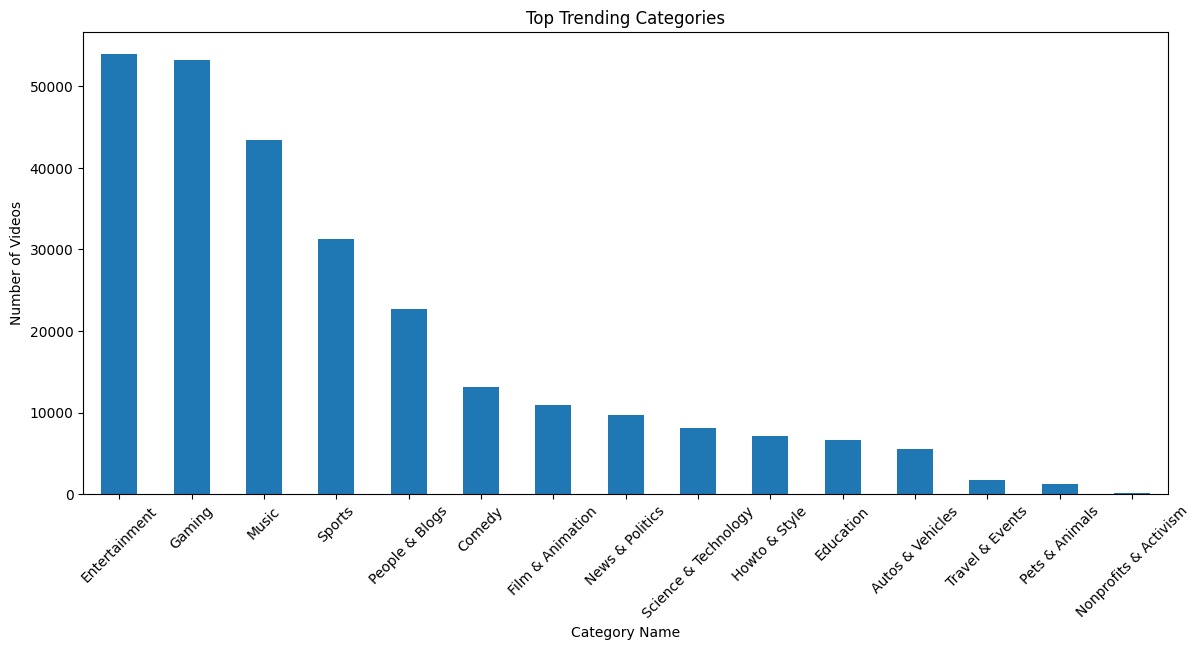

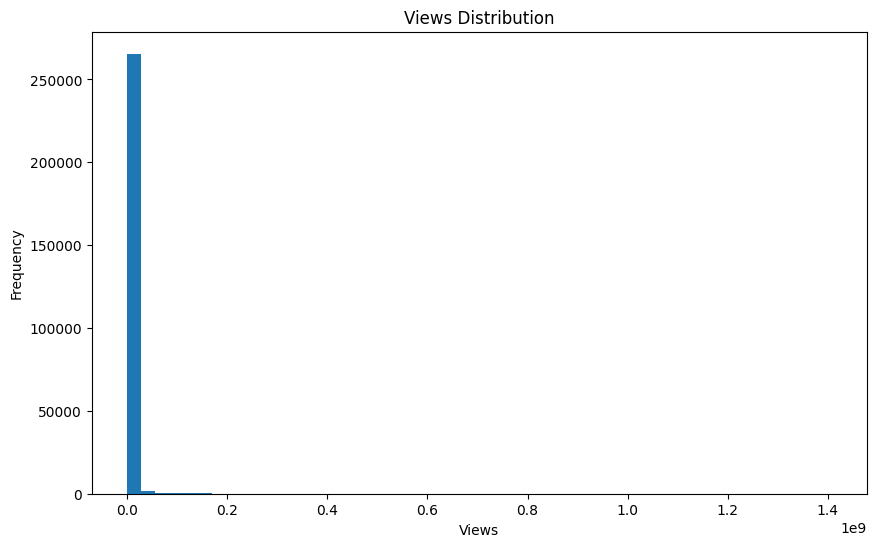

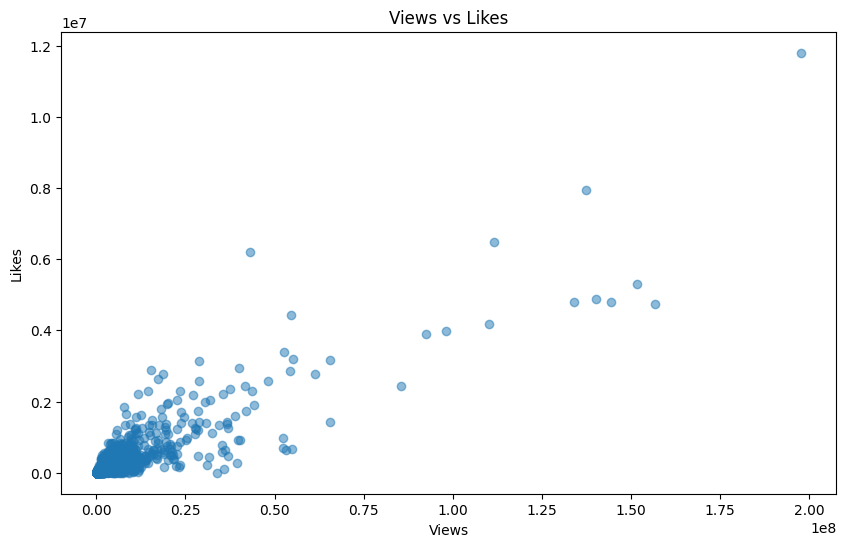

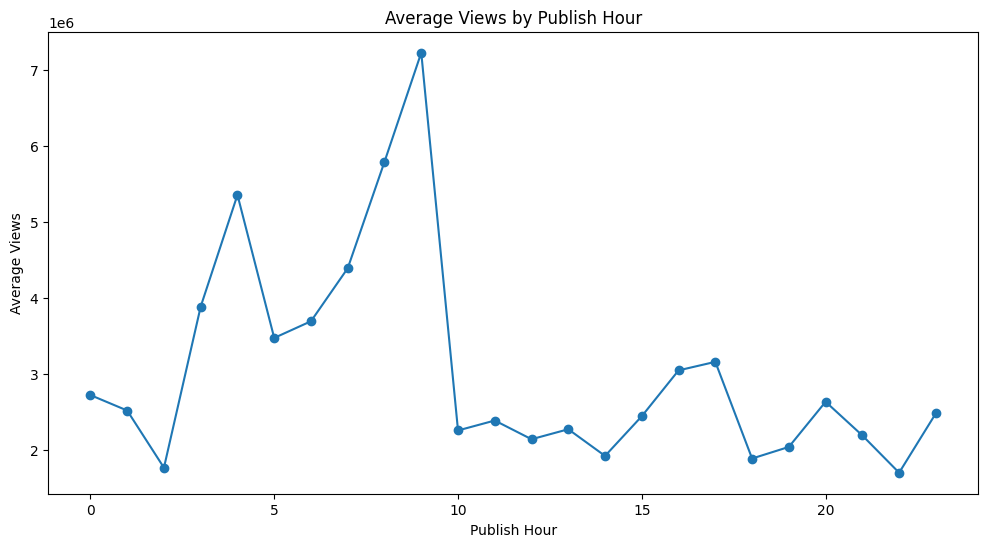

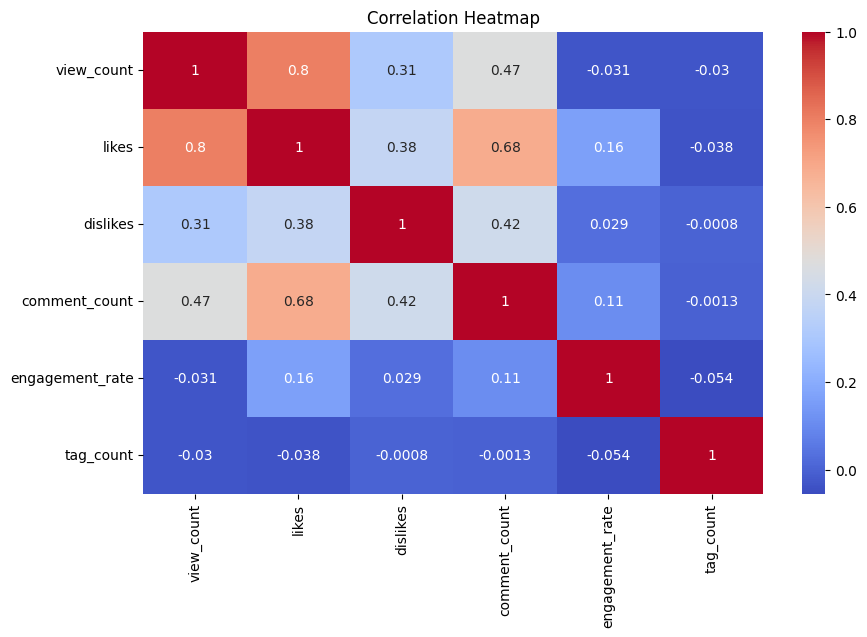

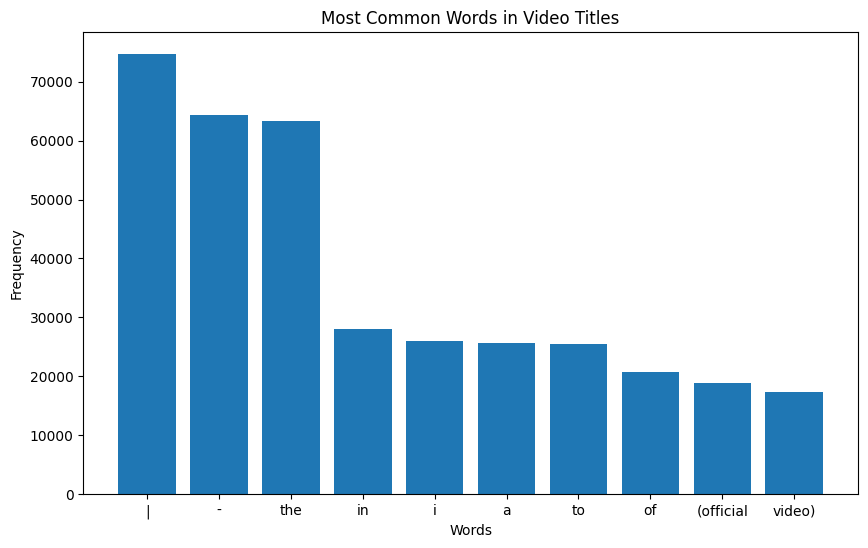

In [ ]:
# Create bar chart
plt.figure(figsize=(14,6))

top_categories.plot(kind='bar')

plt.title("Top Trending Categories")

plt.xlabel("Category Name")

plt.ylabel("Number of Videos")

plt.xticks(rotation=45)

plt.show()

# VIEWS DISTRIBUTION
plt.figure(figsize=(10,6))

plt.hist(df['view_count'], bins=50)

plt.title("Views Distribution")
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()
# LIKES VS VIEWS RELATIONSHIP

# Sample data for faster plotting
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10,6))

plt.scatter(
    sample_df['view_count'],
    sample_df['likes'],
    alpha=0.5
)

plt.title("Views vs Likes")
plt.xlabel("Views")
plt.ylabel("Likes")

plt.show()

# PUBLISH TIME ANALYSIS

publish_hour_views = df.groupby(
    'publish_hour'
)['view_count'].mean()

plt.figure(figsize=(12,6))

publish_hour_views.plot(
    kind='line',
    marker='o'
)

plt.title("Average Views by Publish Hour")
plt.xlabel("Publish Hour")
plt.ylabel("Average Views")

plt.show()
# CORRELATION HEATMAP

numeric_df = df[[
    'view_count',
    'likes',
    'dislikes',
    'comment_count',
    'engagement_rate',
    'tag_count'
]]

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# TITLE WORD ANALYSIS

# Combine all titles
all_titles = ' '.join(df['title'].astype(str))

# Convert to lowercase
words = all_titles.lower().split()

# Count common words
common_words = Counter(words).most_common(10)

# Create dataframe
words_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Count']
)

# Plot
plt.figure(figsize=(10,6))

plt.bar(
    words_df['Word'],
    words_df['Count']
)

plt.title("Most Common Words in Video Titles")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

# ⚙️ Machine Learning Model and Predictions


LINEAR REGRESSION RESULTS
MAE: 1374773.6356446634
R2 Score: 0.5476463395664074

RANDOM FOREST RESULTS
MAE: 839785.0562590834
R2 Score: 0.6522574328886642

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8165296327988393


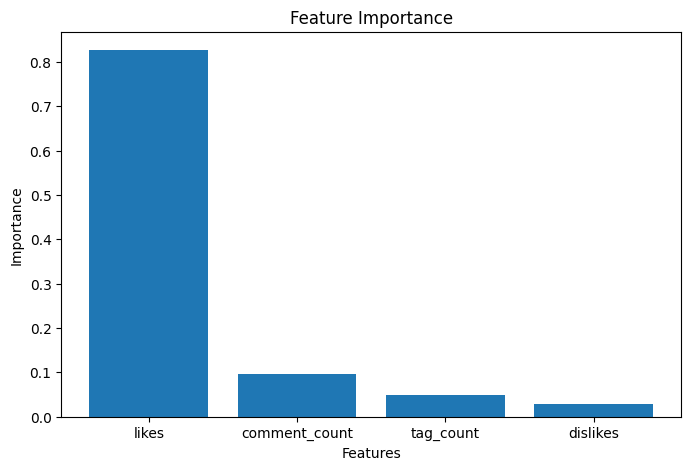

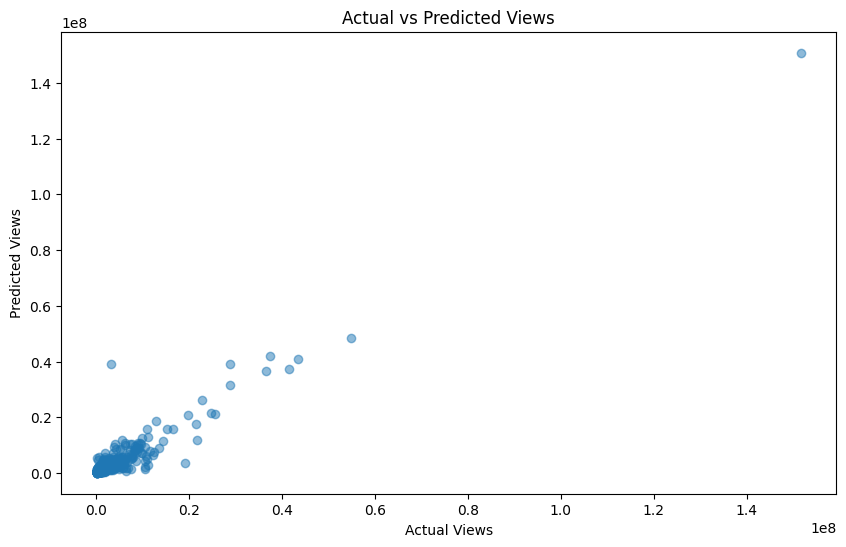


FIRST 5 RANDOM FOREST PREDICTIONS
   Actual Views  Predicted Views
0        546263       1106611.64
1        589224        557629.58
2        249016        536767.90
3        133954        335165.05
4        974385       1056294.74


In [ ]:
# Build models to predict view counts

# Features
X = df [[
    'likes',
    'dislikes',
    'comment_count',
    'tag_count'
]]

# Target
y = df['view_count']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# LINEAR REGRESSION MODEL

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict
lr_predictions = lr_model.predict(X_test)

# Results
print("\nLINEAR REGRESSION RESULTS")

print(
    "MAE:",
    mean_absolute_error(y_test, lr_predictions)
)

print(
    "R2 Score:",
    r2_score(y_test, lr_predictions)
)


# RANDOM FOREST MODEL

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Results
print("\nRANDOM FOREST RESULTS")

print(
    "MAE:",
    mean_absolute_error(y_test, rf_predictions)
)

print(
    "R2 Score:",
    r2_score(y_test, rf_predictions)
)

# TRENDING STATUS PREDICTION

# Predict trending status

# Create trending column
df['trending'] = (
    df['view_count']
    > df['view_count'].median()
).astype(int)

# Features
X_class = df[[
    'likes',
    'dislikes',
    'comment_count',
    'tag_count'
]]

# Target
y_class = df['trending']

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)

# Train
log_model.fit(X_train_c, y_train_c)

# Predict
pred = log_model.predict(X_test_c)

# Accuracy
print("\nLOGISTIC REGRESSION RESULTS")

print(
    "Accuracy:",
    accuracy_score(y_test_c, pred)
)


# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

# ACTUAL VS PREDICTED VIEWS

plt.figure(figsize=(10,6))

plt.scatter(
    y_test[:1000],
    rf_predictions[:1000],
    alpha=0.5
)

plt.title("Actual vs Predicted Views")
plt.xlabel("Actual Views")
plt.ylabel("Predicted Views")

plt.show()

# STEP 20: SHOW SAMPLE PREDICTIONS

print("\nFIRST 5 RANDOM FOREST PREDICTIONS")

results = pd.DataFrame({
    'Actual Views': y_test.values[:5],
    'Predicted Views': rf_predictions[:5]
})

print(results)


# ✅ Conclusion

The project successfully analyzed YouTube video data and applied machine learning techniques to build and evaluate a predictive model. The results demonstrate how data preprocessing, visualization, and model training can be combined to extract meaningful insights and make predictions.